# **IMPORT LIBRARIES**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import gamma, factorial, gammaln
from scipy.stats import poisson, nbinom, chi2
from scipy.optimize import minimize

In [ ]:
#Specify the directory to use
def change_directory():
    # Prompt the user to input the directory path
    directory = input("Please enter the directory path to change to: ")

    # Check if the input is a valid directory
    if os.path.isdir(directory):
        try:
            # Change the current working directory
            os.chdir(directory)
            print(f"Successfully changed the working directory to: {os.getcwd()}")
        except Exception as e:
            print(f"An error occurred while changing the directory: {e}")
    else:
        print(f"Error: '{directory}' is not a valid directory. Please try again.")

# Run the function
change_directory()

Successfully changed the working directory to: C:\Users\Veteran\OneDrive - The University of Texas at Dallas\School\MIS 6386 Modeling for Biz Analytics\Group 7\project-II-group07


# **PART I - REPLICATING MODELS FROM CLASS**

## **Upload Dataset**

In [ ]:
candy = pd.read_csv('candy.csv')
candy.head()

,Packs,People
0,0,102
1,1,54
2,2,49
3,3,62
4,4,44


In [ ]:
# input parameters
packs_candy = np.array(candy['Packs'])
people_candy = np.array(candy['People'])

## **1a. Poisson Model**

### Log-Likelihood Function

In [ ]:
# params (lambda): average number of candy packs purchased over a week
# packs: size of number of candy packs
# people: number of people corresponding to the number of candy packs

def NLL_poisson_candy(params, packs, people):
  # unpack parameters
  plambda = params

  # calculate log probabilities for each number of candy packs
  log_prob = poisson.logpmf(packs, plambda)

  # calculate log-likelihood for each number of candy packs
  ll = people * log_prob

  # sum the negative log-likelihoods
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
# initial guesses for optimizer
poisson_candy_initial_guesses = [np.array([1]), np.array([2.1]), np.array([0.3])]

soln_poisson_candy = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in poisson_candy_initial_guesses:
  soln = minimize(NLL_poisson_candy, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (packs_candy, people_candy), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(0.000001, None)], # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_poisson_candy = soln

# MLE results
params_mle_poisson_candy = soln_poisson_candy.x
print(f'Estimated \u03BB: {params_mle_poisson_candy[0]}')

mll_poisson_candy = -soln_poisson_candy.fun
print(f'Maximum Log-Likelihood: {mll_poisson_candy}')

Estimated λ: 3.991228148584454
Maximum Log-Likelihood: -1544.9963904489673


### Predictions

In [ ]:
# define predict function
def predict_poisson_candy(params, packs, people):
  # unpack parameters
  plambda = params

  # calculate predictions of every number of candy packs
  pred = np.sum(people) * poisson.pmf(packs, plambda)
  return pred

# make predictions
pred_poisson_candy = predict_poisson_candy(params_mle_poisson_candy, packs_candy, people_candy)

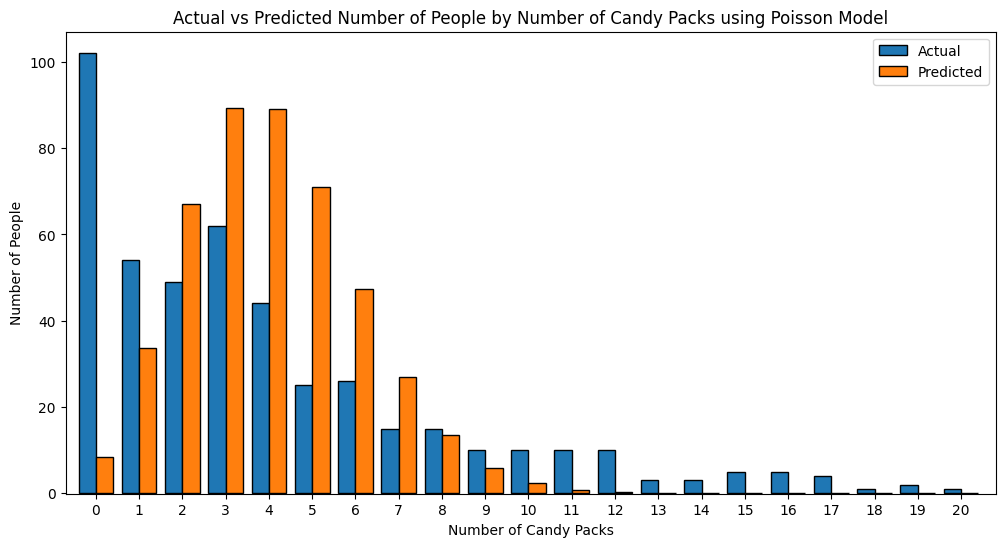

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 21.0])
plt.ylim([-0.1, people_candy.max() + 5])
plt.xlabel('Number of Candy Packs')
plt.ylabel('Number of People')

# define position of bars on x-axis
ind = np.arange(len(packs_candy))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, people_candy, width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_poisson_candy, width = width, edgecolor = 'black', label = 'Predicted', align = 'center')

# add labels, legends, and title
xticks = plt.xticks(ind + width / 2, packs_candy)
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of People by Number of Candy Packs using Poisson Model')
plt.show()

## **1b. NBD Model**

### Log-Likelihood Function

In [ ]:
# params (n, alpha): shape and scale parameters in gamma distribution of lambda
# packs: size of number of candy packs
# people: number of people corresponding to the number of candy packs

def NLL_nbd_candy(params, packs, people):
  # unpack parameters
  n, alpha = params # parameters for gamma distrbution
  (nb_r, nb_p) = (n, alpha / (alpha + 1)) # parameters for negative binomial distribution

  # calculate log probabilities for each number of candy packs
  log_prob = nbinom.logpmf(packs, nb_r, nb_p)

  # calculate log-likelihood for each number of candy packs
  ll = people * log_prob

  # sum the negative log-likelihoods
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
# initial guesses for optimizer
nbd_candy_initial_guesses = [np.array([1, 1]), np.array([2.1, 1.2]), np.array([0.3, 0.7])]

soln_nbd_candy = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in nbd_candy_initial_guesses:
  soln = minimize(NLL_nbd_candy, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (packs_candy, people_candy), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(0.000001, None)] * 2, # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current maximum is even smaller than the best maximum so far
    best_nll = soln.fun # set new best minimum
    soln_nbd_candy = soln

# MLE results
params_mle_nbd_candy = soln_nbd_candy.x
print(f'Estimated n: {params_mle_nbd_candy[0]}\nEstimated \u03B1: {params_mle_nbd_candy[1]}')

mll_nbd_candy = -soln_nbd_candy.fun
print(f'Maximum Log-Likelihood: {mll_nbd_candy}')

Estimated n: 0.9976590570571716
Estimated α: 0.24996293812551423
Maximum Log-Likelihood: -1140.0237461854288


### Predictions

In [ ]:
# define predict function
def predict_nbd_candy(params, packs, people):
  # unpack parameters
  n, alpha = params # parameters for gamma distrbution
  (nb_r, nb_p) = (n, alpha / (alpha + 1)) # parameters for negative binomial distribution


  # calculate predictions of every number of candy packs
  pred = np.sum(people) * nbinom.pmf(packs, nb_r, nb_p)
  return pred

# make predictions
pred_nbd_candy = predict_nbd_candy(params_mle_nbd_candy, packs_candy, people_candy)

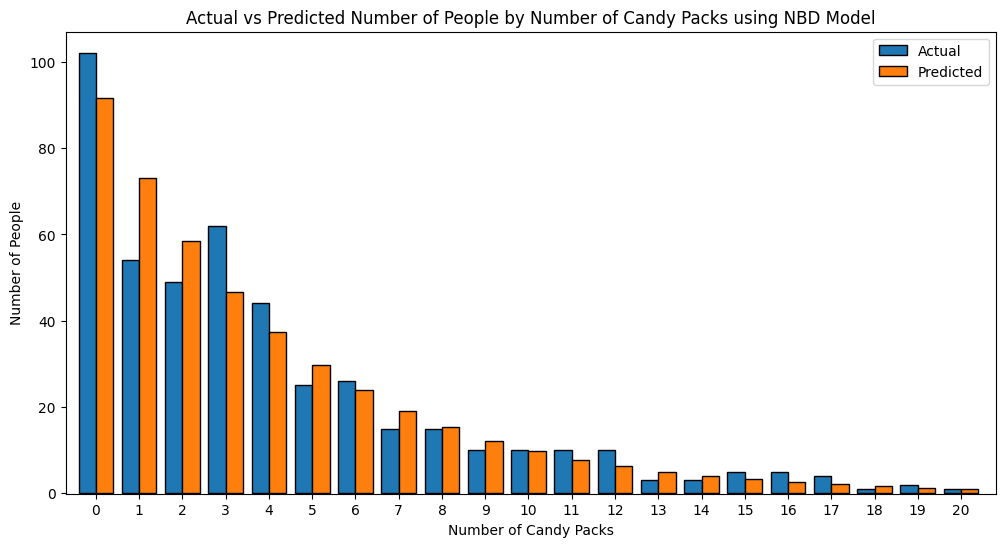

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 21.0])
plt.ylim([-0.1, people_candy.max() + 5])
plt.xlabel('Number of Candy Packs')
plt.ylabel('Number of People')

# define position of bars on x-axis
ind = np.arange(len(packs_candy))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, people_candy, width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_nbd_candy, width = width, edgecolor = 'black', label = 'Predicted', align = 'center')

# add labels, legends, and title
xticks = plt.xticks(ind + width / 2, packs_candy)
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of People by Number of Candy Packs using NBD Model')
plt.show()

## **1c. Zero-Inflated NBD Model**

### Log-Likelihood Function

In [ ]:
# params (pi, n, alpha): (proportion of people who will never purchase the candy, shape and scale parameters in gamma distribution of lambda)
# packs: size of number of candy packs
# people: number of people corresponding to the number of candy packs

def NLL_zinbd_candy(params, packs, people):
  # unpack parameters
  pi, n, alpha = params # parameters for gamma distrbution
  (nb_r, nb_p) = (n, alpha / (alpha + 1)) # parameters for negative binomial distribution

  # calculate log probabilities for non-zero number of candy packs
  log_nbd_probs = np.log(1 - pi) + nbinom.logpmf(packs, nb_r, nb_p)

  # calculate log probability for zero candy packs
  log_zi_prob = np.log(pi + (1 - pi) * nbinom.pmf(0, nb_r, nb_p))

  # calculate log probabilities for each number of candy packs
  log_prob = np.where(packs == 0, log_zi_prob, log_nbd_probs)

  # calculate log-likelihood for each number of candy packs
  ll = people * log_prob

  # sum the negative log-likelihoods
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
# initial guesses for optimizer
zinbd_candy_initial_guesses = [np.array([0.7, 1, 1]), np.array([0.3, 2.1, 1.2]), np.array([0.9, 0.3, 0.7])]

soln_zinbd_candy = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in zinbd_candy_initial_guesses:
  soln = minimize(NLL_zinbd_candy, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (packs_candy, people_candy), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(0.000001, 0.999999)] + [(0.000001, None)] * 2, # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current maximum is even smaller than the best maximum so far
    best_nll = soln.fun # set new best minimum
    soln_zinbd_candy = soln


# MLE results
params_mle_zinbd_candy = soln_zinbd_candy.x
print(f'Estimated \u03C0: {params_mle_zinbd_candy[0]}\nEstimated n: {params_mle_zinbd_candy[1]}\nEstimated \u03B1: {params_mle_zinbd_candy[2]}')

mll_zinbd_candy = -soln_zinbd_candy.fun
print(f'Maximum Log-Likelihood: {mll_zinbd_candy}')

Estimated π: 0.11310496905008534
Estimated n: 1.5039226414115625
Estimated α: 0.33419055500661793
Maximum Log-Likelihood: -1136.1656408414597


### Predictions

In [ ]:
# define predict function
def predict_zinbd_candy(params, packs, people):
  # unpack parameters
  pi, n, alpha = params # parameters for gamma distrbution
  (nb_r, nb_p) = (n, alpha / (alpha + 1)) # parameters for negative binomial distribution

  # calculate predictions for non-zero number of candy packs
  nbd_probs = (1 - pi) * nbinom.pmf(packs, nb_r, nb_p)

  # calculate predictions for zero candy pack
  zi_prob = pi + (1 - pi) * nbinom.pmf(0, nb_r, nb_p)

  # calculate predictions of every number of candy packs
  pred = np.sum(people) * np.where(packs == 0, zi_prob, nbd_probs)
  return pred

# make predictions
pred_zinbd_candy = predict_zinbd_candy(params_mle_zinbd_candy, packs_candy, people_candy)

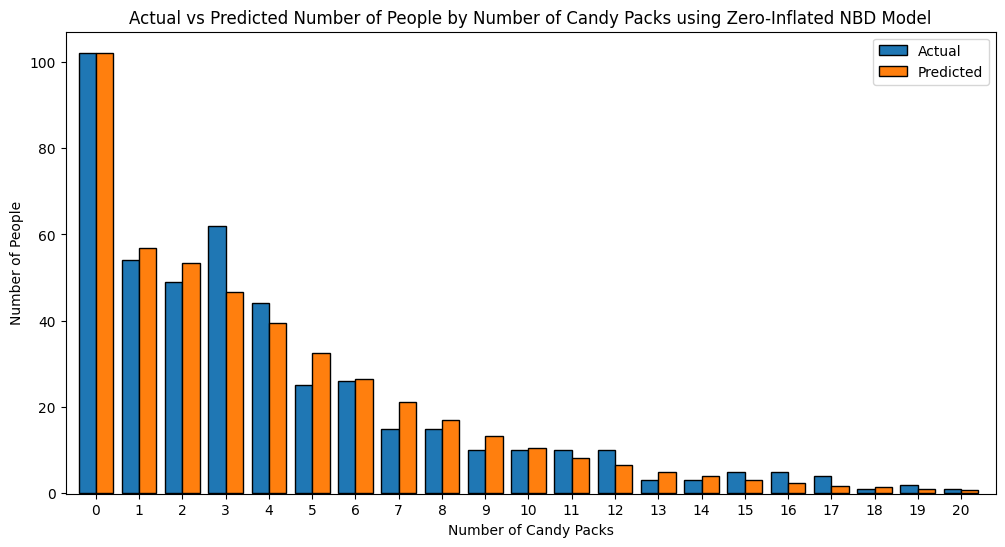

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 21.0])
plt.ylim([-0.1, people_candy.max() + 5])
plt.xlabel('Number of Candy Packs')
plt.ylabel('Number of People')

# define position of bars on x-axis
ind = np.arange(len(packs_candy))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, people_candy, width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_zinbd_candy, width = width, edgecolor = 'black', label = 'Predicted', align = 'center')

# add labels, legends, and title
xticks = plt.xticks(ind + width / 2, packs_candy)
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of People by Number of Candy Packs using Zero-Inflated NBD Model')
plt.show()

## **1d. 2-Segment Finite Mixture Model**

### Log-Likelihood Function

In [ ]:
# params (thetas, lambdas): (re-parametrized mixing proportions, corresponding average number of candy packs purchased over a week)
# packs: size of number of candy packs
# people: number of people corresponding to the number of candy packs
# k: number of segments

def NLL_fm_candy(params, packs, people, k):
  # unpack parameters
  thetas = params[:k] # first k elements are log of the mixing proportions (theta1, theta2, ..., thetak)
  lambdas = params[k:] # next k elements are Poisson rates (lambda1, lambda2, ..., lambdak)

  # set theta of the last segment equal 0 (always)
  thetas[k - 1] = 0

  # convert thetas to mixing proportions pi's
  exp_thetas = np.exp(thetas)
  sum_exp_thetas = np.sum(exp_thetas)
  pis = exp_thetas / sum_exp_thetas

  # calculate probabilities for all packs and all segments (using broadcasting)
  probs = poisson.pmf(packs[:, None], lambdas) # resulting shape is (n_packs, k)

  # calculate weighted sum of probabilities for each number of candy pack
  weighted_probs = np.dot(probs, pis)

  # calculate log-likelihood for each number of candy packs
  ll = people * np.log(weighted_probs)

  # sum the negative log-likelihoods
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
'''
When adapting the log-likelihood function to different k values, the optimizer might be converging to a local minimum rather than finding
distinct segment parameters for other k-segment models.
To address this issue, we vary initial guesses, which help the optimizer explore a broader range of solutions. We then check for local minima,
by running the optimization multiple times with different initial guesses to ensure that the results are not stuck in a local minimum.
'''

# specify number of segments
k = 2

# initial guesses for optimizer - setting the last theta 0 to ensure optimizer starts with the correct assumption
fm_candy_initial_guesses = [np.array([0.5] * (k - 1) + [0.0] + [1, 2]), # Diverse initial guesses
                   np.array([0.1] * (k - 1) + [0.0] + [1, 1.5]),
                   np.array([1.0] * (k - 1) + [0.0] + [0.5, 2])]

soln_fm2_candy = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in fm_candy_initial_guesses:
  soln = minimize(NLL_fm_candy, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (packs_candy, people_candy, k), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(None, None)] * k + [(0.000001, None)] * k, # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_fm2_candy = soln


# MLE results
params_mle_fm2_candy = soln_fm2_candy.x
thetas_mle_fm2_candy = params_mle_fm2_candy[:k]
lambdas_mle_fm2_candy = params_mle_fm2_candy[k:]

print('Estimated \u03B8:')
for i, theta in enumerate(thetas_mle_fm2_candy, start = 1):
  print(f'\u03B8_{i}: {theta:.3f}')

print('\nEstimated \u03C0:')
for i, theta in enumerate(thetas_mle_fm2_candy, start = 1):
  print(f'\u03C0_{i}: {np.exp(theta) / np.sum(np.exp(thetas_mle_fm2_candy)):.3f}')

print('\nEstimated \u03BB:')
for i, lambdai in enumerate(lambdas_mle_fm2_candy, start = 1):
  print(f'\u03BB_{i}: {lambdai:.3f}')

mll_fm2_candy = -soln_fm2_candy.fun
print(f'\nMaximum Log-Likelihood: {mll_fm2_candy}')

Estimated θ:
θ_1: 0.852
θ_2: 0.000

Estimated π:
π_1: 0.701
π_2: 0.299

Estimated λ:
λ_1: 1.802
λ_2: 9.121

Maximum Log-Likelihood: -1188.8328271726098


### Predictions

In [ ]:
# define predict function
def predict_fm_candy(params, packs, people, k):
  # unpack parameters
  thetas = params[:k] # first k elements are log of the mixing proportions (theta1, theta2, ..., thetak)
  lambdas = params[k:] # next k elements are Poisson rates (lambda1, lambda2, ..., lambdak)

  # convert thetas to mixing proportions pi's
  exp_thetas = np.exp(thetas)
  sum_exp_thetas = np.sum(exp_thetas)
  pis = exp_thetas / sum_exp_thetas

  # calculate probabilities for all packs and all segments (using broadcasting)
  probs = poisson.pmf(packs[:, None], lambdas) # resulting shape is (n_packs, k)

  # calculate weighted sum of probabilities for each number of candy pack and multiply by the population size
  pred = np.sum(people) * np.dot(probs, pis)

  return pred

# make predictions
pred_fm2_candy = predict_fm_candy(params_mle_fm2_candy, packs_candy, people_candy, k)

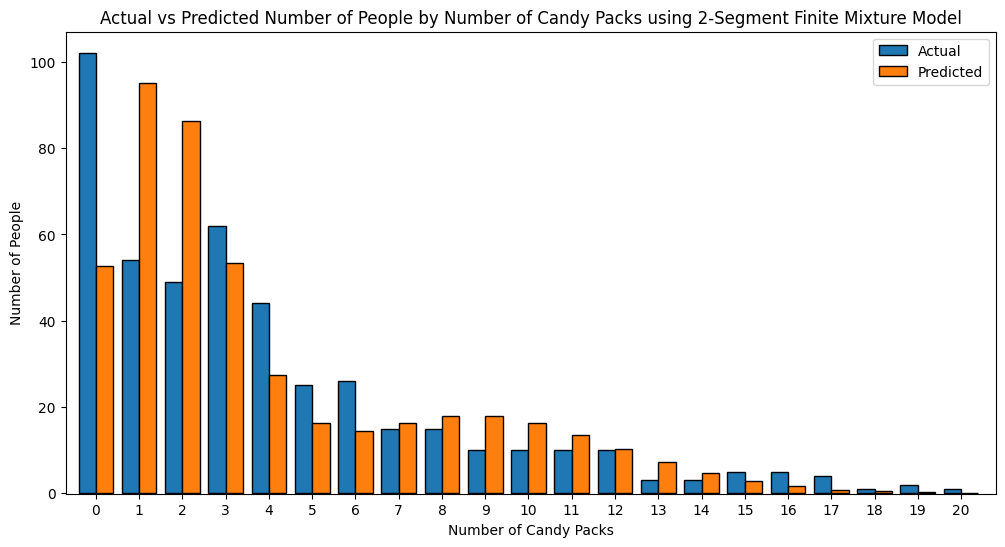

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 21.0])
plt.ylim([-0.1, people_candy.max() + 5])
plt.xlabel('Number of Candy Packs')
plt.ylabel('Number of People')

# define position of bars on x-axis
ind = np.arange(len(packs_candy))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, people_candy, width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_fm2_candy, width = width, edgecolor = 'black', label = 'Predicted', align = 'center')

# add labels, legends, and title
xticks = plt.xticks(ind + width / 2, packs_candy)
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of People by Number of Candy Packs using 2-Segment Finite Mixture Model')
plt.show()

## **1e. 3-Segment Finite Mixture Model**

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
'''
When adapting the log-likelihood function to different k values, the optimizer might be converging to a local minimum rather than finding
distinct segment parameters for other k-segment models.
To address this issue, we vary initial guesses, which help the optimizer explore a broader range of solutions. We then check for local minima,
by running the optimization multiple times with different initial guesses to ensure that the results are not stuck in a local minimum.
'''

# specify number of segments
k = 3

# initial guesses for optimizer - setting the last theta 0 to ensure optimizer starts with the correct assumption
fm_candy_initial_guesses = [np.array([0.5] * (k - 1) + [0.0] + [2, 1, 3]), # Diverse initial guesses
                   np.array([0.1] * (k - 1) + [0.0] + [2.1, 0.5, 1.3]),
                   np.array([1.0] * (k - 1) + [0.0] + [0.35, 1, 1.5])]

soln_fm3_candy = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in fm_candy_initial_guesses:
  soln = minimize(NLL_fm_candy, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (packs_candy, people_candy, k), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(None, None)] * k + [(0.000001, None)] * k, # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_fm3_candy = soln


# MLE results
params_mle_fm3_candy = soln_fm3_candy.x
thetas_mle_fm3_candy = params_mle_fm3_candy[:k]
lambdas_mle_fm3_candy = params_mle_fm3_candy[k:]

print('Estimated \u03B8:')
for i, theta in enumerate(thetas_mle_fm3_candy, start = 1):
  print(f'\u03B8_{i}: {theta:.3f}')

print('\nEstimated \u03C0:')
for i, theta in enumerate(thetas_mle_fm3_candy, start = 1):
  print(f'\u03C0_{i}: {np.exp(theta) / np.sum(np.exp(thetas_mle_fm3_candy)):.3f}')

print('\nEstimated \u03BB:')
for i, lambdai in enumerate(lambdas_mle_fm3_candy, start = 1):
  print(f'\u03BB_{i}: {lambdai:.3f}')

mll_fm3_candy = -soln_fm3_candy.fun
print(f'\nMaximum Log-Likelihood: {mll_fm3_candy}')

Estimated θ:
θ_1: 0.430
θ_2: 1.105
θ_3: 0.000

Estimated π:
π_1: 0.277
π_2: 0.543
π_3: 0.180

Estimated λ:
λ_1: 0.291
λ_2: 3.483
λ_3: 11.216

Maximum Log-Likelihood: -1132.0429842631859


### Predictions

In [ ]:
# make predictions
pred_fm3_candy = predict_fm_candy(params_mle_fm3_candy, packs_candy, people_candy, k)

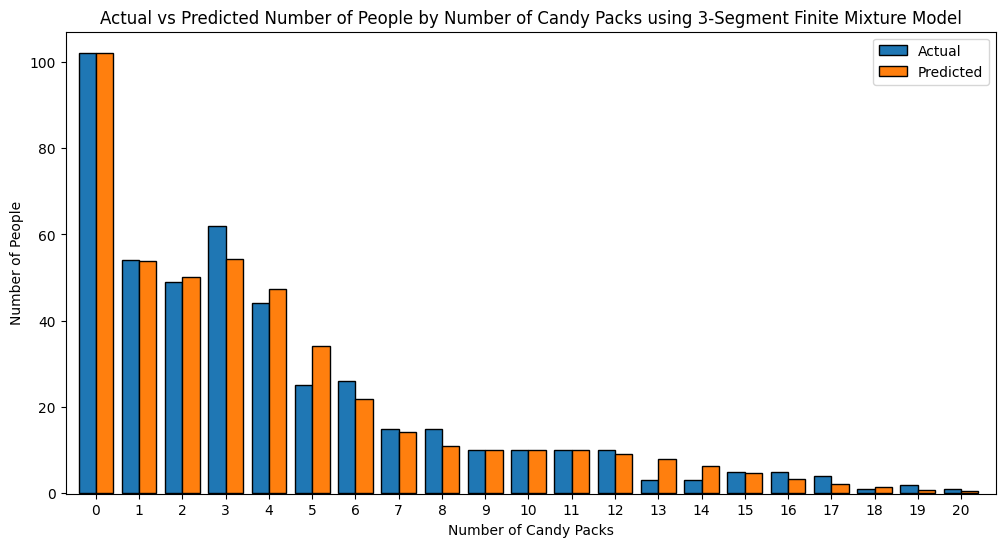

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 21.0])
plt.ylim([-0.1, people_candy.max() + 5])
plt.xlabel('Number of Candy Packs')
plt.ylabel('Number of People')

# define position of bars on x-axis
ind = np.arange(len(packs_candy))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, people_candy, width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_fm3_candy, width = width, edgecolor = 'black', label = 'Predicted', align = 'center')

# add labels, legends, and title
xticks = plt.xticks(ind + width / 2, packs_candy)
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of People by Number of Candy Packs using 3-Segment Finite Mixture Model')
plt.show()

## **1f. 4-Segment Finite Mixture Model**

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
'''
When adapting the log-likelihood function to different k values, the optimizer might be converging to a local minimum rather than finding
distinct segment parameters for other k-segment models.
To address this issue, we vary initial guesses, which help the optimizer explore a broader range of solutions. We then check for local minima,
by running the optimization multiple times with different initial guesses to ensure that the results are not stuck in a local minimum.
'''

# specify number of segments
k = 4

# initial guesses for optimizer - setting the last theta 0 to ensure optimizer starts with the correct assumption
fm_candy_initial_guesses = [np.array([0.5] * (k - 1) + [0.0] + [3, 2, 1, 0]), # Diverse initial guesses
                   np.array([0.1] * (k - 1) + [0.0] + [0.5, 1.3, 2.1, 1.1]),
                   np.array([1.0] * (k - 1) + [0.0] + [1, 1.5, 0.7, 0.35])]

soln_fm4_candy = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in fm_candy_initial_guesses:
  soln = minimize(NLL_fm_candy, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (packs_candy, people_candy, k), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(None, None)] * k + [(0.000001, None)] * k, # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_fm4_candy = soln


# MLE results
params_mle_fm4_candy = soln_fm4_candy.x
thetas_mle_fm4_candy = params_mle_fm4_candy[:k]
lambdas_mle_fm4_candy = params_mle_fm4_candy[k:]

print('Estimated \u03B8:')
for i, theta in enumerate(thetas_mle_fm4_candy, start = 1):
  print(f'\u03B8_{i}: {theta:.3f}')

print('\nEstimated \u03C0:')
for i, theta in enumerate(thetas_mle_fm4_candy, start = 1):
  print(f'\u03C0_{i}: {np.exp(theta) / np.sum(np.exp(thetas_mle_fm4_candy)):.3f}')

print('\nEstimated \u03BB:')
for i, lambdai in enumerate(lambdas_mle_fm4_candy, start = 1):
  print(f'\u03BB_{i}: {lambdai:.3f}')

mll_fm4_candy = -soln_fm4_candy.fun
print(f'\nMaximum Log-Likelihood: {mll_fm4_candy}')

Estimated θ:
θ_1: 0.478
θ_2: 1.200
θ_3: -0.398
θ_4: 0.000

Estimated π:
π_1: 0.244
π_2: 0.503
π_3: 0.102
π_4: 0.151

Estimated λ:
λ_1: 0.205
λ_2: 3.002
λ_3: 12.873
λ_4: 7.418

Maximum Log-Likelihood: -1130.0705910564732


Note: Within our group, π's and λ's are identical but θ's differ. However, the outputs represent the same underlying model. The difference in θ's is purely a numerical artifact of the optimization process and does not affect the model's interpretation or predictions.

### Predictions

In [ ]:
# make predictions
pred_fm4_candy = predict_fm_candy(params_mle_fm4_candy, packs_candy, people_candy, k)

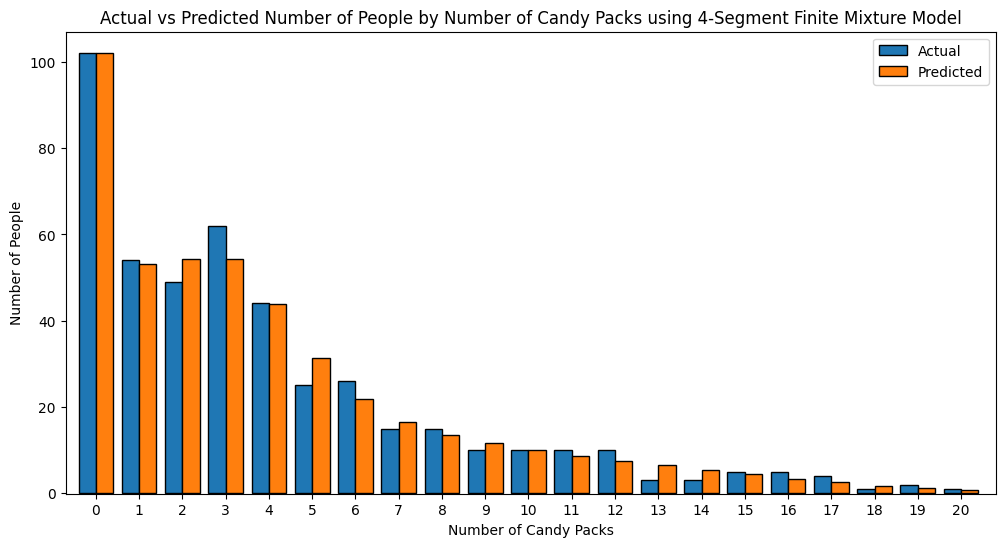

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 21.0])
plt.ylim([-0.1, people_candy.max() + 5])
plt.xlabel('Number of Candy Packs')
plt.ylabel('Number of People')

# define position of bars on x-axis
ind = np.arange(len(packs_candy))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, people_candy, width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_fm4_candy, width = width, edgecolor = 'black', label = 'Predicted', align = 'center')

# add labels, legends, and title
xticks = plt.xticks(ind + width / 2, packs_candy)
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of People by Number of Candy Packs using 4-Segment Finite Mixture Model')
plt.show()

## **2. Model Evaluation**

##### Actual vs. Prediction Comparison

In [ ]:
# create dataframe to organize the data
candy_df_predictions = pd.DataFrame({
    'Packs': packs_candy,
    'Actual People': people_candy,
    'Poisson Pred.': pred_poisson_candy,
    'NBD Pred.': pred_nbd_candy,
    'ZI-NBD Pred.': pred_zinbd_candy,
    '2 SEG FM Pred.': pred_fm2_candy,
    '3 SEG FM Pred.': pred_fm3_candy,
    '4 SEG FM Pred.': pred_fm4_candy
})
candy_df_predictions

,Packs,Actual People,Poisson Pred.,NBD Pred.,ZI-NBD Pred.,2 SEG FM Pred.,3 SEG FM Pred.,4 SEG FM Pred.
0,0,102,8.425515,91.533422,102.000545,52.731432,101.992275,102.171256
1,1,54,33.628155,73.057484,56.839569,95.139374,53.930771,53.081175
2,2,49,67.108819,58.379309,53.336416,86.225845,50.200569,54.377898
3,3,62,89.282202,46.668387,46.691650,53.311215,54.227840,54.350432
4,4,44,89.086409,37.313966,39.405087,27.470446,47.417484,43.915273
5,5,25,71.112837,29.838082,32.511480,16.197549,34.142505,31.249378
6,6,26,47.304593,23.861860,26.414537,14.436261,21.926071,21.921216
7,7,15,26.971917,19.083670,21.223424,16.187453,14.284095,16.512525
8,8,15,13.456385,15.262921,16.909349,17.864360,10.948836,13.513920
9,9,10,5.967500,12.207523,13.383491,17.985638,10.131279,11.573638


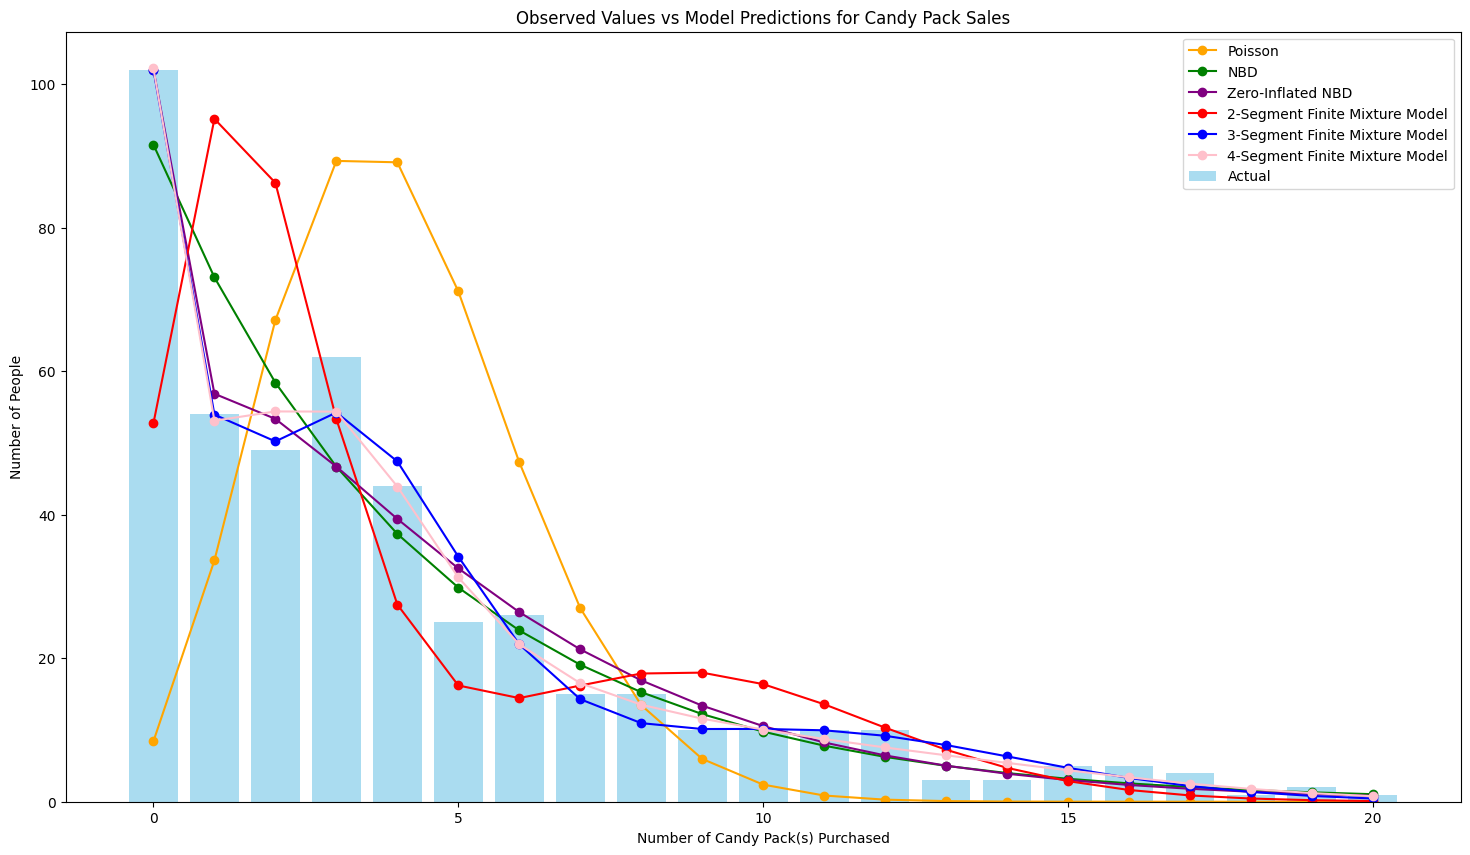

In [ ]:
# actual values
candy_actual_values = candy_df_predictions['Actual People'].values

# predictions from different models
candy_poisson_predictions = candy_df_predictions['Poisson Pred.'].values
candy_nbd_predictions = candy_df_predictions['NBD Pred.'].values
candy_zinbd_predictions = candy_df_predictions['ZI-NBD Pred.'].values
candy_fm2_predictions = candy_df_predictions['2 SEG FM Pred.'].values
candy_fm3_predictions = candy_df_predictions['3 SEG FM Pred.'].values
candy_fm4_predictions = candy_df_predictions['4 SEG FM Pred.'].values

# set up the x-axis
x = np.arange(len(candy_actual_values))

# plot observed values as a bar chart
plt.figure(figsize=(18,10))
plt.bar(x, candy_actual_values, color='skyblue', label='Actual', alpha=0.7)

# plot predictions from each model as line graphs
plt.plot(x, candy_poisson_predictions, color='orange', marker='o', linestyle='-', label='Poisson')
plt.plot(x, candy_nbd_predictions, color='green', marker='o', linestyle='-', label='NBD')
plt.plot(x, candy_zinbd_predictions, color='purple', marker='o', linestyle='-', label='Zero-Inflated NBD')
plt.plot(x, candy_fm2_predictions, color='red', marker='o', linestyle='-', label='2-Segment Finite Mixture Model')
plt.plot(x, candy_fm3_predictions, color='blue', marker='o', linestyle='-', label='3-Segment Finite Mixture Model')
plt.plot(x, candy_fm4_predictions, color='pink', marker='o', linestyle='-', label='4-Segment Finite Mixture Model')

# add labels and title
plt.xlabel('Number of Candy Pack(s) Purchased')
plt.ylabel('Number of People')
plt.title('Observed Values vs Model Predictions for Candy Pack Sales')
plt.legend()

# show the plot
plt.show()

In [ ]:
"""
Note: Number of parameters in finite mixture models are reduced by 1 due to theta/pi of the last segment can be determined by the others (theta set equal to 0)
"""
# store model results in a dictionary
models_candy = {'Poisson': {'Number of Parameters': len(soln_poisson_candy.x), 'Maximum Log-Likelihood': mll_poisson_candy},
                'NBD': {'Number of Parameters': len(soln_nbd_candy.x), 'Maximum Log-Likelihood': mll_nbd_candy},
                'ZI-NBD': {'Number of Parameters': len(soln_zinbd_candy.x), 'Maximum Log-Likelihood': mll_zinbd_candy},
                '2 SEG FM': {'Number of Parameters': len(soln_fm2_candy.x) - 1, 'Maximum Log-Likelihood': mll_fm2_candy},
                '3 SEG FM': {'Number of Parameters': len(soln_fm3_candy.x) - 1, 'Maximum Log-Likelihood': mll_fm3_candy},
                '4 SEG FM': {'Number of Parameters': len(soln_fm4_candy.x) - 1, 'Maximum Log-Likelihood': mll_fm4_candy} }

# create summary dataframe
summary_candy = pd.DataFrame.from_dict(models_candy, orient = 'index')

# reset index to have 'Model' as a column
summary_candy = summary_candy.reset_index().rename(columns = {'index': 'Model'})

# calculate AIC and BIC
summary_candy['AIC'] = 2 * summary_candy['Number of Parameters'] - 2 * summary_candy['Maximum Log-Likelihood']
summary_candy['BIC'] = np.log(np.sum(people_candy)) * summary_candy['Number of Parameters'] - 2 * summary_candy['Maximum Log-Likelihood']

summary_candy

,Model,Number of Parameters,Maximum Log-Likelihood,AIC,BIC
0,Poisson,1,-1544.996390,3091.992781,3096.115274
1,NBD,2,-1140.023746,2284.047492,2292.292478
2,ZI-NBD,3,-1136.165641,2278.331282,2290.698760
3,2 SEG FM,3,-1188.832827,2383.665654,2396.033133
4,3 SEG FM,5,-1132.042984,2274.085969,2294.698433
5,4 SEG FM,7,-1130.070591,2274.141182,2302.998632


In [ ]:
# sort the summary dataframe by AIC and BIC to get rankings
candy_aic_ranking = summary_candy.sort_values(by = 'AIC').reset_index(drop=True)
candy_bic_ranking = summary_candy.sort_values(by = 'BIC').reset_index(drop=True)

# add ranking columns for clarity
candy_aic_ranking['AIC Rank'] = range(1, len(candy_aic_ranking) + 1)
candy_bic_ranking['BIC Rank'] = range(1, len(candy_bic_ranking) + 1)

# display the rankings
print('Ranking by AIC (Lowest to Highest):')
print(candy_aic_ranking[['Model', 'AIC', 'AIC Rank']])

print('\nRanking by BIC (Lowest to Highest):')
print(candy_bic_ranking[['Model', 'BIC', 'BIC Rank']])

Ranking by AIC (Lowest to Highest):
      Model          AIC  AIC Rank
0  3 SEG FM  2274.085969         1
1  4 SEG FM  2274.141182         2
2    ZI-NBD  2278.331282         3
3       NBD  2284.047492         4
4  2 SEG FM  2383.665654         5
5   Poisson  3091.992781         6

Ranking by BIC (Lowest to Highest):
      Model          BIC  BIC Rank
0    ZI-NBD  2290.698760         1
1       NBD  2292.292478         2
2  3 SEG FM  2294.698433         3
3  4 SEG FM  2302.998632         4
4  2 SEG FM  2396.033133         5
5   Poisson  3096.115274         6


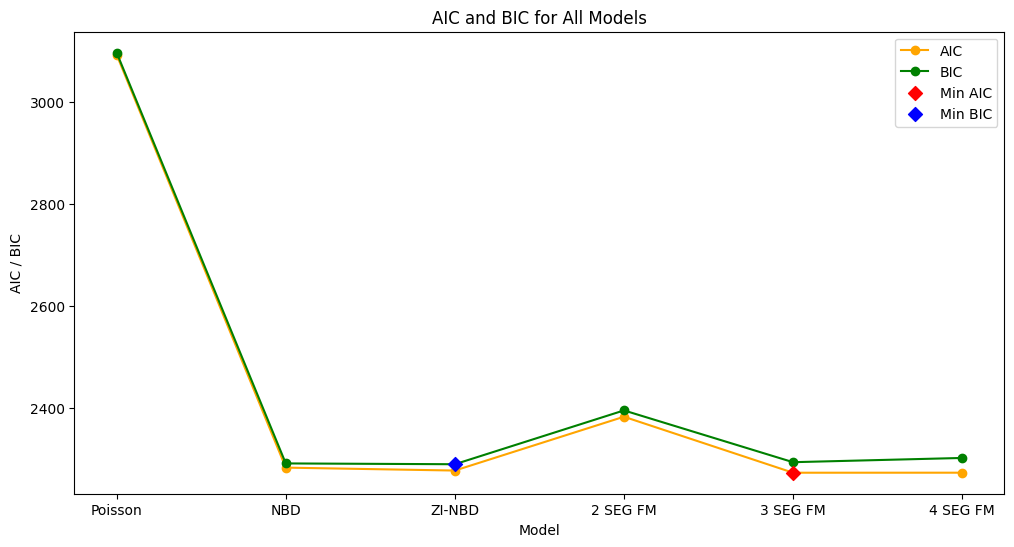

In [ ]:
# find the index of the minimum AIC and BIC values
min_aic_index = summary_candy['AIC'].idxmin()
min_bic_index = summary_candy['BIC'].idxmin()

# plot AIC and BIC by model
plt.figure(figsize=(12,6))

plt.plot(summary_candy['AIC'], color = 'orange', marker = 'o', label = 'AIC')
plt.plot(summary_candy['BIC'], color = 'green', marker = 'o', label = 'BIC')

# highlight the smallest AIC and BIC values
plt.scatter(min_aic_index, summary_candy['AIC'].min(), color = 'red', marker = 'D', s = 50, zorder = 5, label = 'Min AIC')
plt.scatter(min_bic_index, summary_candy['BIC'].min(), color = 'blue', marker = 'D', s = 50, zorder = 5, label = 'Min BIC')

# add labels, legends, and title
plt.xticks(ticks = np.arange(len(summary_candy['Model'])), labels = summary_candy['Model'])
plt.xlabel('Model')
plt.ylabel('AIC / BIC')
plt.legend()
plt.title('AIC and BIC for All Models')

# show the plot
plt.show()

In [ ]:
# define nested models for log-likelihood ratio test
pairs_to_compare = [('Poisson', 'NBD'), ('Poisson', 'ZI-NBD'), ('NBD', 'ZI-NBD'),
                    ('2 SEG FM', '3 SEG FM'), ('2 SEG FM', '4 SEG FM'), ('3 SEG FM', '4 SEG FM')]

# initialize an empty list to store log-likelihood ratios
lrt_results_candy = []

# iterate through all possible pairs of models
for model1, model2 in pairs_to_compare:
  # get the log-likelihoods and number of parameters for the 2 models
  ll1 = summary_candy.loc[summary_candy['Model'] == model1, 'Maximum Log-Likelihood'].values[0]
  ll2 = summary_candy.loc[summary_candy['Model'] == model2, 'Maximum Log-Likelihood'].values[0]

  df1 = summary_candy.loc[summary_candy['Model'] == model1, 'Number of Parameters'].values[0]
  df2 = summary_candy.loc[summary_candy['Model'] == model2, 'Number of Parameters'].values[0]

  # log-likelihood ratio
  lr_stat = 2 * (ll2 - ll1)

  # calculate difference in df
  df_diff = abs(df2 - df1)

  # calculate p-value from chi-squared distribution
  p_value = 1 - chi2.cdf(lr_stat, df_diff)
  p_value = round(p_value, 5)
  better_model = model2 if p_value < 0.05 else model1

  # append the result
  lrt_results_candy.append({
        'Simple Model': model1,
        'Complex Model': model2,
        'Log-Likelihood Ratio': lr_stat,
        'Degrees of Freedom Difference': df_diff,
        'Chi-Squared p-value': p_value,
        'Better Model': better_model})

# create a dataframe to store the pairwise results
lrt_results_candy_df = pd.DataFrame(lrt_results_candy)

lrt_results_candy_df

,Simple Model,Complex Model,Log-Likelihood Ratio,Degrees of Freedom Difference,Chi-Squared p-value,Better Model
0,Poisson,NBD,809.945289,1,0.00000,NBD
1,Poisson,ZI-NBD,817.661499,2,0.00000,ZI-NBD
2,NBD,ZI-NBD,7.716211,1,0.00547,ZI-NBD
3,2 SEG FM,3 SEG FM,113.579686,2,0.00000,3 SEG FM
4,2 SEG FM,4 SEG FM,117.524472,4,0.00000,4 SEG FM
5,3 SEG FM,4 SEG FM,3.944786,2,0.13912,3 SEG FM


## **3. Predictions for the Next 8 Weeks**

### Direct Prediction

In [ ]:
# pack = number of candy purchased in the past week
# define predict function for 8 weeks

fm_params = {'2 SEG FM': {'params': params_mle_fm2_candy},
             '3 SEG FM': {'params': params_mle_fm3_candy},
             '4 SEG FM': {'params': params_mle_fm4_candy}
             }

# packs purchased in the past week
observed_packs = [5, 9]
weeks = 8

# function to predict packs for a customer using FMM
def predict_yweeks_fm_candy1(params, pack, k, weeks):
  # unpack parameters
  thetas = params[:k] # first k elements are log of the mixing proportions (theta1, theta2, ..., thetak)
  lambdas = params[k:] # next k elements are Poisson rates (lambda1, lambda2, ..., lambdak)

  # convert thetas to mixing proportions pi's
  exp_thetas = np.exp(thetas)
  sum_exp_thetas = np.sum(exp_thetas)
  pis = exp_thetas / sum_exp_thetas

  # calculate posterior proportions (P[s = j | x = pack])
  probs = poisson.pmf(pack, lambdas) # probabilities P[x = pack | s = j]
  pis_times_probs =  pis * probs # components of the denominator of the bayes theorem
  posterior_probs = pis_times_probs / np.sum(pis_times_probs)

  # calculate weighted sum of the expected number of purchases
  pred = np.sum(lambdas * posterior_probs)

  # calculate the prediction for the next y weeks
  pred = pred * weeks

  return pred

In [ ]:
# loop through each predicted pack and each segment model
pred_8w_candy1 = {}
for model, values in fm_params.items():
  params = values['params']
  k = len(params) // 2 # number of segments
  pred_8w_candy1[model] = {}
  for pack in observed_packs:
    pred = predict_yweeks_fm_candy1(params, pack, k, weeks)
    pred_8w_candy1[model][f'Predict {pack} packs'] = pred

# display the predictions
for model, results in pred_8w_candy1.items():
  print(f'Predictions using {model} for {weeks} weeks:')
  for observation, prediction in results.items():
    print(f'  {observation}: {prediction:.4f} packs')
  print()

Predictions using 2 SEG FM for 8 weeks:
  Predict 5 packs: 42.7806 packs
  Predict 9 packs: 72.8707 packs

Predictions using 3 SEG FM for 8 weeks:
  Predict 5 packs: 30.8253 packs
  Predict 9 packs: 80.0633 packs

Predictions using 4 SEG FM for 8 weeks:
  Predict 5 packs: 33.6717 packs
  Predict 9 packs: 69.4529 packs



### Classification before Prediction

In [ ]:
# pack = number of candy purchased in the past week
# define predict function for 8 weeks

# function to classify customer into segment
def predict_yweeks_fm_candy2(params, pack, k, weeks):
  # unpack parameters
  thetas = params[:k] # first k elements are log of the mixing proportions (theta1, theta2, ..., thetak)
  lambdas = params[k:] # next k elements are Poisson rates (lambda1, lambda2, ..., lambdak)

  # convert thetas to mixing proportions pi's
  exp_thetas = np.exp(thetas)
  sum_exp_thetas = np.sum(exp_thetas)
  pis = exp_thetas / sum_exp_thetas

  # calculate posterior proportions (P[s = j | x = pack])
  probs = poisson.pmf(pack, lambdas) # probabilities P[x = pack | s = j]
  pis_times_probs =  pis * probs # components of the denominator of the bayes theorem
  posterior_probs = pis_times_probs / np.sum(pis_times_probs)

  # classifying customer into segment with the highest posterior probs
  idx = np.argmax(posterior_probs) # index of maximum probability
  segment = idx + 1 # convert 0-index to 1-index

  # calculate the prediction for the next y weeks
  pred = lambdas[idx] * weeks

  return segment, posterior_probs, pred

In [ ]:
# loop through observed packs for classification and predictions
pred_8w_candy2 = {}
for model, values in fm_params.items():
  params = values['params']
  k = len(params) // 2 # number of segments
  pred_8w_candy2[model] = {}
  for pack in observed_packs:
    segment, posterior_probs, pred = predict_yweeks_fm_candy2(params, pack, k, weeks)
    pred_8w_candy2[model][f'Observed {pack} packs'] = {
        'Predicted Packs': pred,
        'Assigned Segment': segment,
        'Posterior Probabilities': posterior_probs
    }

# display the predictions
for model, results in pred_8w_candy2.items():
  print(f'Classification and Predictions using {model} for {weeks} weeks:')
  for observation, details in results.items():
    print(f'  {observation}:')
    print(f'    Predicted Packs: {details["Predicted Packs"]:.2f}')
    print(f'    Assigned Segment: {details["Assigned Segment"]}')
    print(f'    Posterior Probabilities: {details["Posterior Probabilities"]}')
  print()

Classification and Predictions using 2 SEG FM for 8 weeks:
  Observed 5 packs:
    Predicted Packs: 14.42
    Assigned Segment: 1
    Posterior Probabilities: [0.51555654 0.48444346]
  Observed 9 packs:
    Predicted Packs: 72.97
    Assigned Segment: 2
    Posterior Probabilities: [0.00161952 0.99838048]

Classification and Predictions using 3 SEG FM for 8 weeks:
  Observed 5 packs:
    Predicted Packs: 27.87
    Assigned Segment: 2
    Posterior Probabilities: [4.76898857e-05 9.52104592e-01 4.78477185e-02]
  Observed 9 packs:
    Predicted Packs: 89.73
    Assigned Segment: 3
    Posterior Probabilities: [3.78684125e-10 1.56210806e-01 8.43789194e-01]

Classification and Predictions using 4 SEG FM for 8 weeks:
  Observed 5 packs:
    Predicted Packs: 24.02
    Assigned Segment: 2
    Posterior Probabilities: [8.70213837e-06 7.40521558e-01 1.12221060e-02 2.48247633e-01]
  Observed 9 packs:
    Predicted Packs: 59.34
    Assigned Segment: 4
    Posterior Probabilities: [1.36490342e-11 5

### Combine Results into a DataFrame

In [ ]:
# create a dataframe to house the predictions and classifications
pred_8w_data = []

# loop through each model and observed packs
for model, values in fm_params.items():
  params = values['params']
  k = len(params) // 2 # number of segments
  for pack in observed_packs:
    # get direct predictions
    pred1 = predict_yweeks_fm_candy1(params, pack, k, weeks)
    # get classified predictions
    segment, posterior_probs, pred2 = predict_yweeks_fm_candy2(params, pack, k, weeks)
    highest_prob = posterior_probs[segment - 1]
    # append the results to the list
    pred_8w_data.append({
        'Model': model,
        'Observed Packs': pack,
        'Direct Predicted Packs': round(pred1, 4),
        'Classified Predicted Packs': round(pred2, 4),
        'Assigned Segment': segment
    })

# convert the list of results to a dataframe
pred_8w_df = pd.DataFrame(pred_8w_data)

# display the dataframe
pred_8w_df

,Model,Observed Packs,Direct Predicted Packs,Classified Predicted Packs,Assigned Segment
0,2 SEG FM,5,42.7806,14.4172,1
1,2 SEG FM,9,72.8707,72.9655,2
2,3 SEG FM,5,30.8253,27.8666,2
3,3 SEG FM,9,80.0633,89.7265,3
4,4 SEG FM,5,33.6717,24.0152,2
5,4 SEG FM,9,69.4529,59.3447,4


# **PART II - ANALYSIS OF NEW DATA**

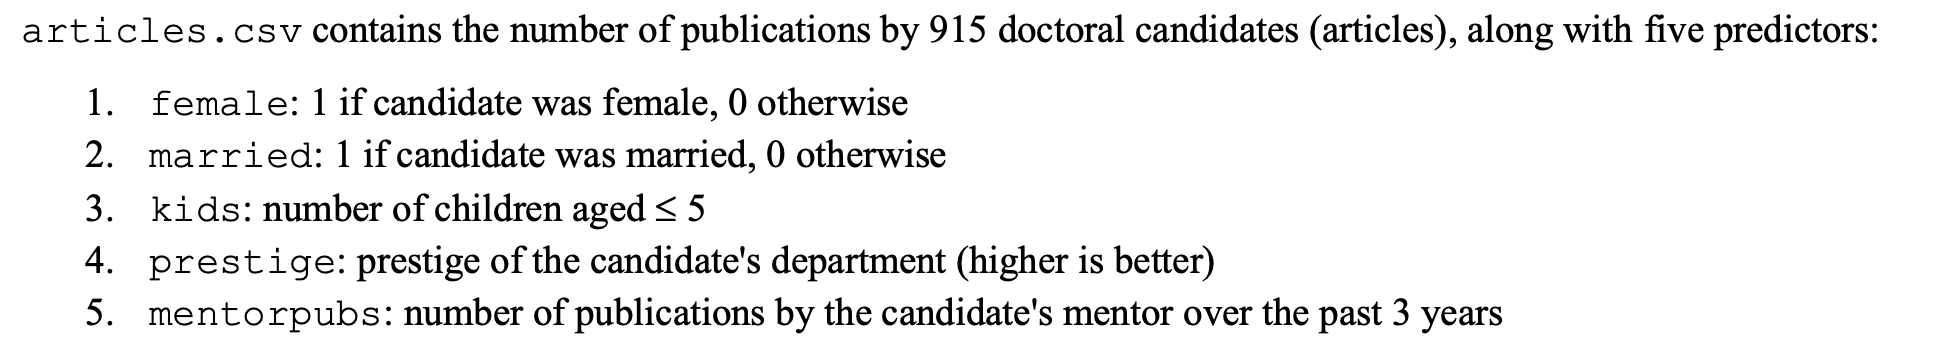

## **Upload Dataset**

In [ ]:
articles = pd.read_csv('articles.csv')
articles.head()

,articles,female,married,kids,prestige,menpubs
0,0,0,1,0,2.52,7
1,0,1,0,0,2.05,6
2,0,1,0,0,3.75,6
3,0,0,1,1,1.18,3
4,0,1,0,0,3.75,26


In [ ]:
# input parameters
y = np.array(articles['articles'])
X = articles.copy()
X = np.array(X.drop(['articles'], axis = 1))

## **1. Poisson Regression**

### Log-Likelihood Function

In [ ]:
# params: lambda0, betas - parameters used to calculate the average number of articles by each doctoral candidate
# X: characteristic variables
# y: number of articles by each doctoral candidate

def NLL_poisson_reg_articles(params, X, y):
  # unpack parameters
  lambda0, *betas = params

  # calculate lambda for each candidate
  lambdas = lambda0 * np.exp(X @ np.array(betas))

  # calculate log-likelihood for each candidate
  ll = poisson.logpmf(y, lambdas)

  # sum the negative log-likelihood
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
# initial guesses for optimizer - diversify initial guesses to check for global maximum
poisson_reg_articles_initial_guesses = [np.array([1.5, 1.1, 1.2, 1.3, -1.4, 1.5]),
                                        np.array([2.1, 1.9, 3.7, -4.1, 1.6, -1.5]),
                                        np.array([0.1, -0.2, -0.4, 0.5, -0.7, 0.9])]

soln_poisson_reg_articles = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in poisson_reg_articles_initial_guesses:
  soln = minimize(NLL_poisson_reg_articles, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (X, y), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(0.000001, None)] + [(None, None)] * X.shape[1], # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_poisson_reg_articles = soln

# MLE results
params_mle_poisson_reg_articles = soln_poisson_reg_articles.x
lambda0_mle_poisson_reg_articles, *betas_mle_poisson_reg_articles = params_mle_poisson_reg_articles

print(f'Estimated \u03BB_0: {lambda0_mle_poisson_reg_articles}')

print(f'\nEstimated \u03B2:')
for i, beta in enumerate(betas_mle_poisson_reg_articles, start = 1):
  print(f'\u03B2_{i}: {beta}')

mll_poisson_reg_articles = -soln_poisson_reg_articles.fun
print(f'\nMaximum Log-Likelihood: {mll_poisson_reg_articles}')

C:\Users\Veteran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
C:\Users\Veteran\AppData\Local\Temp\ipykernel_54696\3621391829.py:10: RuntimeWarning: overflow encountered in exp
  lambdas = lambda0 * np.exp(X @ np.array(betas))
C:\Users\Veteran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_discrete_distns.py:962: RuntimeWarning: invalid value encountered in subtract
  Pk = special.xlogy(k, mu) - gamln(k + 1) - mu


Estimated λ_0: 1.356714038007524

Estimated β:
β_1: -0.22427921889623992
β_2: 0.1559013376310553
β_3: -0.18468654117939237
β_4: 0.01258128711584563
β_5: 0.025530259600231628

Maximum Log-Likelihood: -1651.0565473854197


### Predictions

In [ ]:
# define predict function
def predict_poisson_reg_articles(params, X, y):
  # unpack parameters
  lambda_0, *betas = params

  # calculate lambda for each candidate
  lambdas = lambda_0 * np.exp(X @ np.array(betas))

  # get unique values of y to calculate probabilities for each unique count
  unique_counts = np.unique(y)

  # create a PMF matrix for each unique count k across all candidates
  pmf_matrix = np.array([
      poisson.pmf(unique_counts, lambda_i) for lambda_i in lambdas])

  # sum probabilities across all candidates for each k value
  pred = np.sum(pmf_matrix, axis = 0)

  # sort dictionary by k value
  pred_dict = dict(zip(unique_counts, pred))
  pred_dict = dict(sorted(pred_dict.items()))

  # create a dataframe to store predicted counts
  pred_df = pd.DataFrame({'Number of Articles': list(pred_dict.keys()),
                          'Predicted Number of Candidates': list(pred_dict.values())})

  # create a dataframe to store actual counts
  actual_df = articles.groupby('articles').size().reset_index() # size() counts the number of rows in each group of number of articles value
  actual_df.columns = ['Number of Articles', 'Actual Number of Candidates']

  # merge actual and predicted counts
  pred_df = pred_df.merge(actual_df, on = 'Number of Articles', how = 'left').fillna(0)

  # combine groups with 20+ articles
  pred_df_combined = pred_df.copy()
  pred_df_combined.loc[pred_df_combined['Number of Articles'] > 20, 'Number of Articles'] = '20+'
  pred_df_combined = pred_df_combined.groupby('Number of Articles').sum().reset_index()

  return pred_df_combined

# make predictions
pred_poisson_reg_articles = predict_poisson_reg_articles(params_mle_poisson_reg_articles, X, y)
pred_poisson_reg_articles

C:\Users\Veteran\AppData\Local\Temp\ipykernel_54696\1575704768.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20+' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_df_combined.loc[pred_df_combined['Number of Articles'] > 20, 'Number of Articles'] = '20+'


,Number of Articles,Predicted Number of Candidates,Actual Number of Candidates
0,0,191.336724,275
1,1,283.479572,246
2,2,221.557542,178
3,3,123.264405,84
4,4,55.995262,67
5,5,22.843038,27
6,6,9.091600,17
7,7,3.785826,12
8,8,1.716277,1
9,9,0.850356,2


#### Step-by-Step Calculation of P(X = 5) in Poisson Regression

1. **Calculate the Expected Count \( λi \)**

   For each observation \( i \), the expected count \(λi\) is given by:

   $$
   \lambda_i = \lambda_0 \times \exp(\beta_1 x_{1,i} + \beta_2 x_{2,i} + \beta_3 x_{3,i} + \beta_4 x_{4,i} + \beta_5 x_{5,i})
   $$

   where:
   - λ0 ≈ 1.3567
   - β1 ≈ -0.2243
   - β2 ≈ 0.1559
   - β3 ≈ -0.1847
   - β4 ≈ 0.0126
   - β5 ≈ 0.0255

   For example, the first record has the following values:
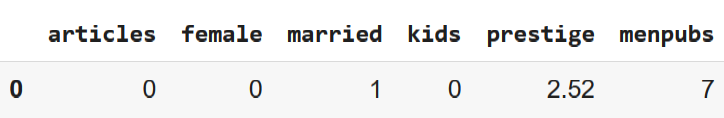

   $$
\lambda = 1.3567 \cdot \exp\left((-0.2243 \cdot 0) + (0.1559 \cdot 1) + (-0.1847 \cdot 0) + (0.0126 \cdot 2.52) + (0.0255 \cdot 7)\right)
$$


2. **Compute P(X = 5) for Each Candidates**

   We use the Poisson probability mass function (PMF) to compute the probability that each candidate has exactly 5 articles, given by:

   $$
   P(X = 5 | \lambda_i) = \frac{\lambda_i^5 \exp(-\lambda_i)}{5!}
   $$

3. **Calculate P(X = 5) by Summation**

 We then sum up all the probabilities of exactly 2 articles across all observations.
   $$
   P(X = 5) ≈ 22.843
   $$


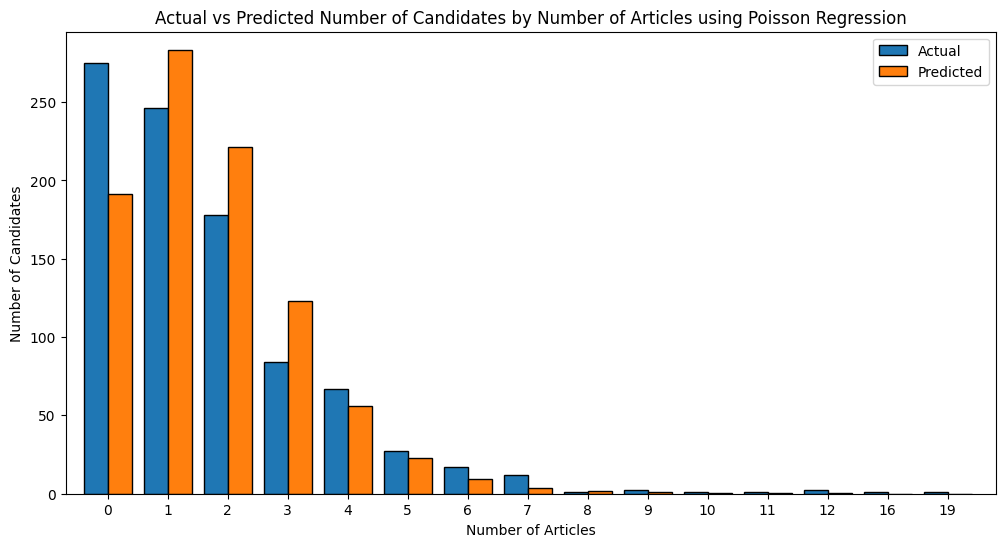

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 15.0])
plt.ylim([-0.1, pred_poisson_reg_articles['Actual Number of Candidates'].max() + 20])
plt.xlabel('Number of Articles')
plt.ylabel('Number of Candidates')

# define position of bars on x-axis
ind = np.arange(len(pred_poisson_reg_articles['Number of Articles']))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, pred_poisson_reg_articles['Actual Number of Candidates'], width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_poisson_reg_articles['Predicted Number of Candidates'], width = width, edgecolor = 'black', label = 'Predicted', align = 'center')
xticks = plt.xticks(ind + width / 2, pred_poisson_reg_articles['Number of Articles'])
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of Candidates by Number of Articles using Poisson Regression')
plt.show()

## **2. NBD Regression**

### Log-Likelihood Function

In [ ]:
# params: n, alpha, betas - parameters used to calculate the average number of articles by each doctoral candidate
# X: characteristic variables
# y: number of articles by each doctoral candidate

def NLL_nbd_reg_articles(params, X, y):
  # unpack parameters
  n, alpha, *betas = params

  # calculate exp(beta * X) for each candidate
  exp_betaX = np.exp(X @ np.array(betas))

  # calculate log-likelihood components for each candidate
  p1 = gammaln(n + y) - gammaln(n) - gammaln(y + 1) # gamma(k+1) = k! -> gammaln(k+1) = ln(k!)
  p2 = n * (np.log(alpha) - np.log(alpha + exp_betaX))
  p3 = y * (np.log(exp_betaX) - np.log(alpha + exp_betaX))

  # sum the log-likelihood components
  ll = p1 + p2 + p3

  # sum the negative log-likelihood
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

In [ ]:
# params: n, alpha, betas - parameters used to calculate the average number of articles by each doctoral candidate
# X: characteristic variables
# y: number of articles by each doctoral candidate

def NLL_nbd_reg_articles(params, X, y):
  # unpack parameters
  n, alpha, *betas = params

  # calculate exp(beta * X) for each candidate
  exp_betaX = np.exp(X @ np.array(betas))

  # calculate the probability p for the negative binomial distribution
  p = alpha / (alpha + exp_betaX)

  # calculate log-likelihood for each candidate
  ll = nbinom.logpmf(y, n, p)

  # sum the negative log-likelihood
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
# initial guesses for optimizer - diversify initial guesses to check for global maximum
nbd_reg_articles_initial_guesses = [np.array([0.8, 1.5, 1.1, 1.2, 1.3, -1.4, 1.5]),
                                        np.array([1.2, 2.1, 1.9, 3.7, -4.1, 1.6, -1.5]),
                                        np.array([0.3, 0.1, -0.2, -0.4, 0.5, -0.7, 0.9])]

soln_nbd_reg_articles = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in nbd_reg_articles_initial_guesses:
  soln = minimize(NLL_nbd_reg_articles, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (X, y), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(0.000001, None)] * 2 + [(None, None)] * X.shape[1], # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_nbd_reg_articles = soln

# MLE results
params_mle_nbd_reg_articles = soln_nbd_reg_articles.x
n_mle_nbd_reg_articles, alpha_mle_nbd_reg_articles, *betas_mle_nbd_reg_articles = params_mle_nbd_reg_articles

print(f'Estimated n: {n_mle_nbd_reg_articles}')
print(f'\nEstimated \u03B1: {alpha_mle_nbd_reg_articles}')

print(f'\nEstimated \u03B2:')
for i, beta in enumerate(betas_mle_nbd_reg_articles, start = 1):
  print(f'\u03B2_{i}: {beta}')

mll_nbd_reg_articles = -soln_nbd_reg_articles.fun
print(f'\nMaximum Log-Likelihood: {mll_nbd_reg_articles}')

C:\Users\Veteran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


Estimated n: 2.2640172397285374

Estimated α: 1.7522990337908533

Estimated β:
β_1: -0.21636421275016396
β_2: 0.1504755222587234
β_3: -0.1764084290588648
β_4: 0.015222300316545201
β_5: 0.029087009266776532

Maximum Log-Likelihood: -1560.958341299273


### Predictions

In [ ]:
# define predict function
def predict_nbd_reg_articles(params, X, y):
  # unpack parameters
  n, alpha, *betas = params

  # calculate exp(beta * X) for each candidate
  exp_betaX = np.exp(X @ np.array(betas))

  # get unique values of y to calculate probabilities for each unique count
  unique_counts = np.unique(y)

  # calculate the probability p for the negative binomial distribution
  p = alpha / (alpha + exp_betaX)

  # create a PMF matrix for each unique count k across all candidates
  pmf_matrix = np.array([
      nbinom.pmf(unique_counts, n, p_i) for p_i in p])

  # sum probabilities across all candidates for each k value
  pred = np.sum(pmf_matrix, axis = 0)

  # sort dictionary by k value
  pred_dict = dict(zip(unique_counts, pred))
  pred_dict = dict(sorted(pred_dict.items()))

  # create a dataframe to store predicted counts
  pred_df = pd.DataFrame({'Number of Articles': list(pred_dict.keys()),
                          'Predicted Number of Candidates': list(pred_dict.values())})

  # create a dataframe to store actual counts
  actual_df = articles.groupby('articles').size().reset_index() # size() counts the number of rows in each group of number of articles value
  actual_df.columns = ['Number of Articles', 'Actual Number of Candidates']

  # merge actual and predicted counts
  pred_df = pred_df.merge(actual_df, on = 'Number of Articles', how = 'left').fillna(0)

  # combine groups with 20+ articles
  pred_df_combined = pred_df.copy()
  pred_df_combined.loc[pred_df_combined['Number of Articles'] > 20, 'Number of Articles'] = '20+'
  pred_df_combined = pred_df_combined.groupby('Number of Articles').sum().reset_index()

  return pred_df_combined

# make predictions
pred_nbd_reg_articles = predict_nbd_reg_articles(params_mle_nbd_reg_articles, X, y)
pred_nbd_reg_articles

C:\Users\Veteran\AppData\Local\Temp\ipykernel_54696\2169343950.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20+' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_df_combined.loc[pred_df_combined['Number of Articles'] > 20, 'Number of Articles'] = '20+'


,Number of Articles,Predicted Number of Candidates,Actual Number of Candidates
0,0,277.808275,275
1,1,249.120381,246
2,2,164.737337,178
3,3,97.294604,84
4,4,54.723860,67
5,5,30.244636,27
6,6,16.739223,17
7,7,9.400372,12
8,8,5.408409,1
9,9,3.209895,2


#### Step-by-Step Calculation of P(X = 5) in NBD Regression

1. **Calculate the Expected Count $(\mu_i)$**

   For each observation \(i\), the expected count $(\mu_i)$ is given by:

   $$
   \mu_i = \exp(\beta_1 x_{1,i} + \beta_2 x_{2,i} + \beta_3 x_{3,i} + \beta_4 x_{4,i} + \beta_5 x_{4,i})
   $$

   where:
   - β1 ≈ -0.2163
   - β2 ≈ 0.1505
   - β3 ≈ -0.1764
   - β4 ≈ 0.0153
   - β5 ≈ 0.0291

   For example, the first record has the following values: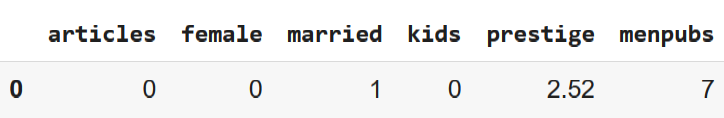
   $$
\mu = \exp\left((-0.2164 \cdot 0) + (0.1505 \cdot 1) + (-0.1764 \cdot 0) + (0.0153 \cdot 2.52) + (0.0291 \cdot 7)\right)
$$


2. **Compute P(X = 5) for Each Candidate**

   For each observation, we use the Negative Binomial probability mass function (PMF) to compute the probability that each individual has exactly 2 exposures, given by:

   $$
   p = \frac{\mu_i}{\alpha + \mu_i}
   $$

   $$
   P(X = 5 | \mu_i) = \frac{\Gamma(n + 5)}{\Gamma(n) \times 5!} \times p^{n} \times (1 - p)^{5}
   $$
   
   where:
   - n ≈ 2.2641
   - α ≈ 1.7526


3. **Calculate P(X = 5) by Summation**

 We then sum up all the probabilities of exactly 2 articles across all observations.
   $$
   P(X = 5) ≈ 30.247
   $$


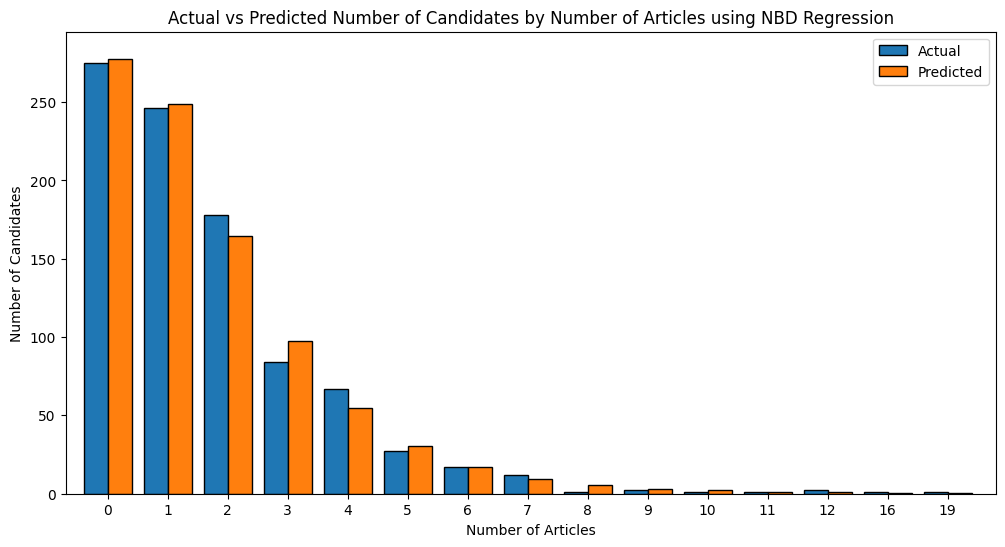

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 15.0])
plt.ylim([-0.1, pred_nbd_reg_articles['Actual Number of Candidates'].max() + 20])
plt.xlabel('Number of Articles')
plt.ylabel('Number of Candidates')

# define position of bars on x-axis
ind = np.arange(len(pred_nbd_reg_articles['Number of Articles']))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, pred_nbd_reg_articles['Actual Number of Candidates'], width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_nbd_reg_articles['Predicted Number of Candidates'], width = width, edgecolor = 'black', label = 'Predicted', align = 'center')
xticks = plt.xticks(ind + width / 2, pred_nbd_reg_articles['Number of Articles'])
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of Candidates by Number of Articles using NBD Regression')
plt.show()

## **3. Zero-Inflated NBD Regression**
First, recall that zero-inflated models view 0s as coming from 2 sources – (i) from a fraction $\pi$ who is 0 “by type”
(in the context of this problem, these are candidates who will never publish), and (ii) from the remaining fraction
$(1 - \pi)$ who are likely to eventually become nonzero (these are candidates who will publish at some point, but have
not done so yet). You can assume that the candidates in the latter group are distributed as a negative binomial
(making the NBD regression appropriate for them).

### Log-Likelihood Function

In [ ]:
# params: pi - proportion of candidates who will not publish any articles;
# n, alpha, betas - parameters used to calculate the average number of articles by each doctoral candidate
# X: characteristic variables
# y: number of articles by each doctoral candidate

def NLL_zinbd_reg_articles(params, X, y):
  # unpack parameters
  pi, n, alpha, *betas = params

  # calculate exp(beta * X) for each candidate
  exp_betaX = np.exp(X @ np.array(betas))

  # calculate the probability p for the negative binomial distribution
  p = alpha / (alpha + exp_betaX)

  # calculate log probabilities for non-zero number of articles
  log_nbd_probs = np.log(1 - pi) + nbinom.logpmf(y, n, p)

  # calculate log probability for zero articles
  log_zi_prob = np.log(pi + (1 - pi) * nbinom.pmf(0, n, p))

  # calculate log-likelihood for each candidate
  ll = np.where(y == 0, log_zi_prob, log_nbd_probs)

  # sum the negative log-likelihood
  nll = -np.sum(ll)

  return nll # return the negative log-likelihood

### Estimated Parameters and Maximum Log-Likelihood

In [ ]:
# initial guesses for optimizer - diversify initial guesses to check for global maximum
zinbd_reg_articles_initial_guesses = [np.array([0.1, 0.8, 1.5, 1.1, 1.2, 1.3, -1.4, 1.5]),
                                        np.array([0.5, 1.2, 2.1, 1.9, 3.7, -4.1, 1.6, -1.5]),
                                        np.array([0.9, 0.3, 0.1, -0.2, -0.4, 0.5, -0.7, 0.9])]

soln_zinbd_reg_articles = None
best_nll = float('inf')

# run the optimizer multiple times with different initial guesses
for initial_guess in zinbd_reg_articles_initial_guesses:
  soln = minimize(NLL_zinbd_reg_articles, # minimize the negative log-likelihood (equivalent to maximizing the log-likelihood)
                              args = (X, y), # input parameters (not to be altered by the solver)
                              x0 = initial_guess, # initial guesses for parameters
                              bounds = [(0.000001, 0.999999)] + [(0.000001, None)] * 2 + [(None, None)] * X.shape[1], # bounds for decision variables
                              tol = 1e-10, # convergence tolerance
                              options = {'ftol': 1e-8} # fractional tolerance
                              )
  if soln.fun < best_nll: # check if the current minimum is even smaller than the best minimum so far
    best_nll = soln.fun # set new best minimum
    soln_zinbd_reg_articles = soln

# MLE results
params_mle_zinbd_reg_articles = soln_zinbd_reg_articles.x
pi_mle_zinbd_reg_articles, n_mle_zinbd_reg_articles, alpha_mle_zinbd_reg_articles, *betas_mle_zinbd_reg_articles = params_mle_zinbd_reg_articles

print(f'Estimated \u03C0: {pi_mle_zinbd_reg_articles}')
print(f'\nEstimated n: {n_mle_zinbd_reg_articles}')
print(f'\nEstimated \u03B1: {alpha_mle_zinbd_reg_articles}')

print(f'\nEstimated \u03B2:')
for i, beta in enumerate(betas_mle_zinbd_reg_articles, start = 1):
  print(f'\u03B2_{i}: {beta}')

mll_zinbd_reg_articles = -soln_zinbd_reg_articles.fun
print(f'\nMaximum Log-Likelihood: {mll_zinbd_reg_articles}')

Estimated π: 1e-06

Estimated n: 2.2644788838270102

Estimated α: 1.7524917212099163

Estimated β:
β_1: -0.21643579538446064
β_2: 0.1503881919766217
β_3: -0.17644424755273871
β_4: 0.015254590297760523
β_5: 0.02908303612952493

Maximum Log-Likelihood: -1560.9583894502832


C:\Users\Veteran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


### Predictions

In [ ]:
# define predict function
def predict_zinbd_reg_articles(params, X, y):
  # unpack parameters
  pi, n, alpha, *betas = params

  # calculate exp(beta * X) for each candidate
  exp_betaX = np.exp(X @ np.array(betas))

  # get unique values of y to calculate probabilities for each unique count
  unique_counts = np.unique(y)

  # calculate the probability p for the negative binomial distribution
  p = alpha / (alpha + exp_betaX)

  # create a PMF matrix for each unique count k across all candidates
  pmf_matrix = np.array([
      (1 - pi) * nbinom.pmf(unique_counts, n, p_i) for p_i in p])

  # add zero-inflated probabilities for count 0 (first column of pmf_matrix)
  pmf_matrix[:, 0] += pi

  # sum probabilities across all candidates for each k value
  pred = np.sum(pmf_matrix, axis = 0)

  # sort dictionary by k value
  pred_dict = dict(zip(unique_counts, pred))
  pred_dict = dict(sorted(pred_dict.items()))

  # create a dataframe to store predicted counts
  pred_df = pd.DataFrame({'Number of Articles': list(pred_dict.keys()),
                          'Predicted Number of Candidates': list(pred_dict.values())})

  # create a dataframe to store actual counts
  actual_df = articles.groupby('articles').size().reset_index() # size() counts the number of rows in each group of number of articles value
  actual_df.columns = ['Number of Articles', 'Actual Number of Candidates']

  # merge actual and predicted counts
  pred_df = pred_df.merge(actual_df, on = 'Number of Articles', how = 'left').fillna(0)

  # combine groups with 20+ articles
  pred_df_combined = pred_df.copy()
  pred_df_combined.loc[pred_df_combined['Number of Articles'] > 20, 'Number of Articles'] = '20+'
  pred_df_combined = pred_df_combined.groupby('Number of Articles').sum().reset_index()

  return pred_df_combined

# make predictions
pred_zinbd_reg_articles = predict_zinbd_reg_articles(params_mle_zinbd_reg_articles, X, y)
pred_zinbd_reg_articles

C:\Users\Veteran\AppData\Local\Temp\ipykernel_54696\1942971110.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20+' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_df_combined.loc[pred_df_combined['Number of Articles'] > 20, 'Number of Articles'] = '20+'


,Number of Articles,Predicted Number of Candidates,Actual Number of Candidates
0,0,277.781058,275
1,1,249.122629,246
2,2,164.747301,178
3,3,97.302570,84
4,4,54.728522,67
5,5,30.246948,27
6,6,16.740209,17
7,7,9.400697,12
8,8,5.408434,1
9,9,3.209800,2


#### Step-by-Step Calculation of P(X = 5) in ZI-NBD Regression

1. **Calculate the Expected Count $(\mu_i)$**

   For each observation \(i\), the expected count $(\mu_i)$ is given by:

   $$
   \mu_i = \exp(\beta_1 x_{1,i} + \beta_2 x_{2,i} + \beta_3 x_{3,i} + \beta_4 x_{4,i} + \beta_5 x_{4,i})
   $$

   where:
   - β1 ≈ -0.2164
   - β2 ≈ 0.1504
   - β3 ≈ -0.1768
   - β4 ≈ 0.0152
   - β5 ≈ 0.0291

   For example, the first record has the following values:

   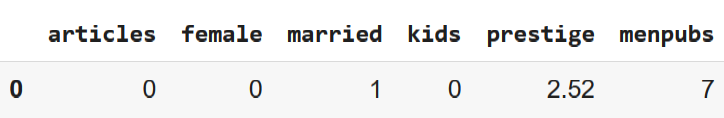

   $$
\mu = \exp\left((-0.2164 \cdot 0) + (0.1504 \cdot 1) + (-0.1768 \cdot 0) + (0.0152 \cdot 2.52) + (0.0291 \cdot 7)\right)
$$


2. **Compute P(X = 5) for Each Candidate**

   For each observation, we use the Negative Binomial probability mass function (PMF) to compute the probability that each individual has exactly 2 exposures, given by:

   $$
   p = \frac{\mu_i}{\alpha + \mu_i}
   $$

   $$
   P(X = 5 | \mu_i) = (1 - \pi) \times \frac{\Gamma(n + 5)}{\Gamma(n) \times 5!} \times p^{n} \times (1 - p)^{5}
   $$
   
   where:
   - π ≈ 1e-06
   - n ≈ 2.2644
   - α ≈ 1.7519


3. **Calculate P(X = 5) by Summation**

 We then sum up all the probabilities of exactly 2 articles across all observations.
   $$
   P(X = 5) ≈ 30.239
   $$

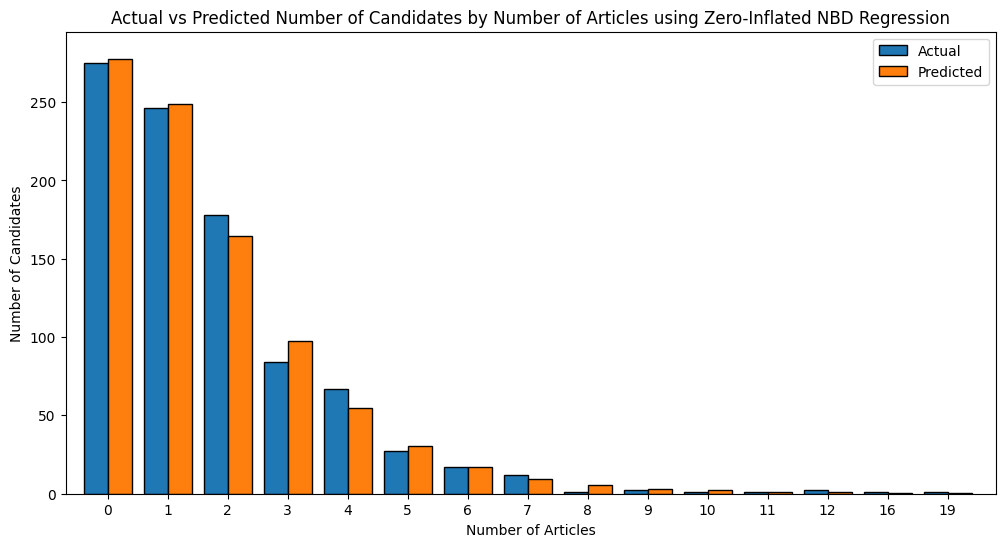

In [ ]:
# plot actual vs predicted values
plt.figure(figsize=(12,6))

# define axis limits and labels
plt.xlim([-0.5, 15.0])
plt.ylim([-0.1, pred_zinbd_reg_articles['Actual Number of Candidates'].max() + 20])
plt.xlabel('Number of Articles')
plt.ylabel('Number of Candidates')

# define position of bars on x-axis
ind = np.arange(len(pred_zinbd_reg_articles['Number of Articles']))

# define width of a bar
width = 0.4

# plot side-by-side bar charts
plt.bar(ind, pred_zinbd_reg_articles['Actual Number of Candidates'], width = width, edgecolor = 'black', label = 'Actual', align = 'center')
plt.bar(ind + width, pred_zinbd_reg_articles['Predicted Number of Candidates'], width = width, edgecolor = 'black', label = 'Predicted', align = 'center')
xticks = plt.xticks(ind + width / 2, pred_zinbd_reg_articles['Number of Articles'])
plt.legend(loc = 'upper right')
plt.title('Actual vs Predicted Number of Candidates by Number of Articles using Zero-Inflated NBD Regression')
plt.show()

## **4. Model Evaluation**

In [ ]:
# combine results into a single dataframe
articles_df_predictions = pred_poisson_reg_articles.copy()
articles_df_predictions = articles_df_predictions.rename(columns = {'Predicted Number of Candidates': 'Poisson Regression Pred.'})
articles_df_predictions['NBD Regression Pred.'] = pred_nbd_reg_articles['Predicted Number of Candidates']
articles_df_predictions['ZI-NBD Regression Pred.'] = pred_zinbd_reg_articles['Predicted Number of Candidates']

# reorder the columns
articles_df_predictions = articles_df_predictions[['Number of Articles', 'Actual Number of Candidates', 'Poisson Regression Pred.', 'NBD Regression Pred.', 'ZI-NBD Regression Pred.']]
articles_df_predictions

,Number of Articles,Actual Number of Candidates,Poisson Regression Pred.,NBD Regression Pred.,ZI-NBD Regression Pred.
0,0,275,191.336724,277.808275,277.781058
1,1,246,283.479572,249.120381,249.122629
2,2,178,221.557542,164.737337,164.747301
3,3,84,123.264405,97.294604,97.302570
4,4,67,55.995262,54.723860,54.728522
5,5,27,22.843038,30.244636,30.246948
6,6,17,9.091600,16.739223,16.740209
7,7,12,3.785826,9.400372,9.400697
8,8,1,1.716277,5.408409,5.408434
9,9,2,0.850356,3.209895,3.209800


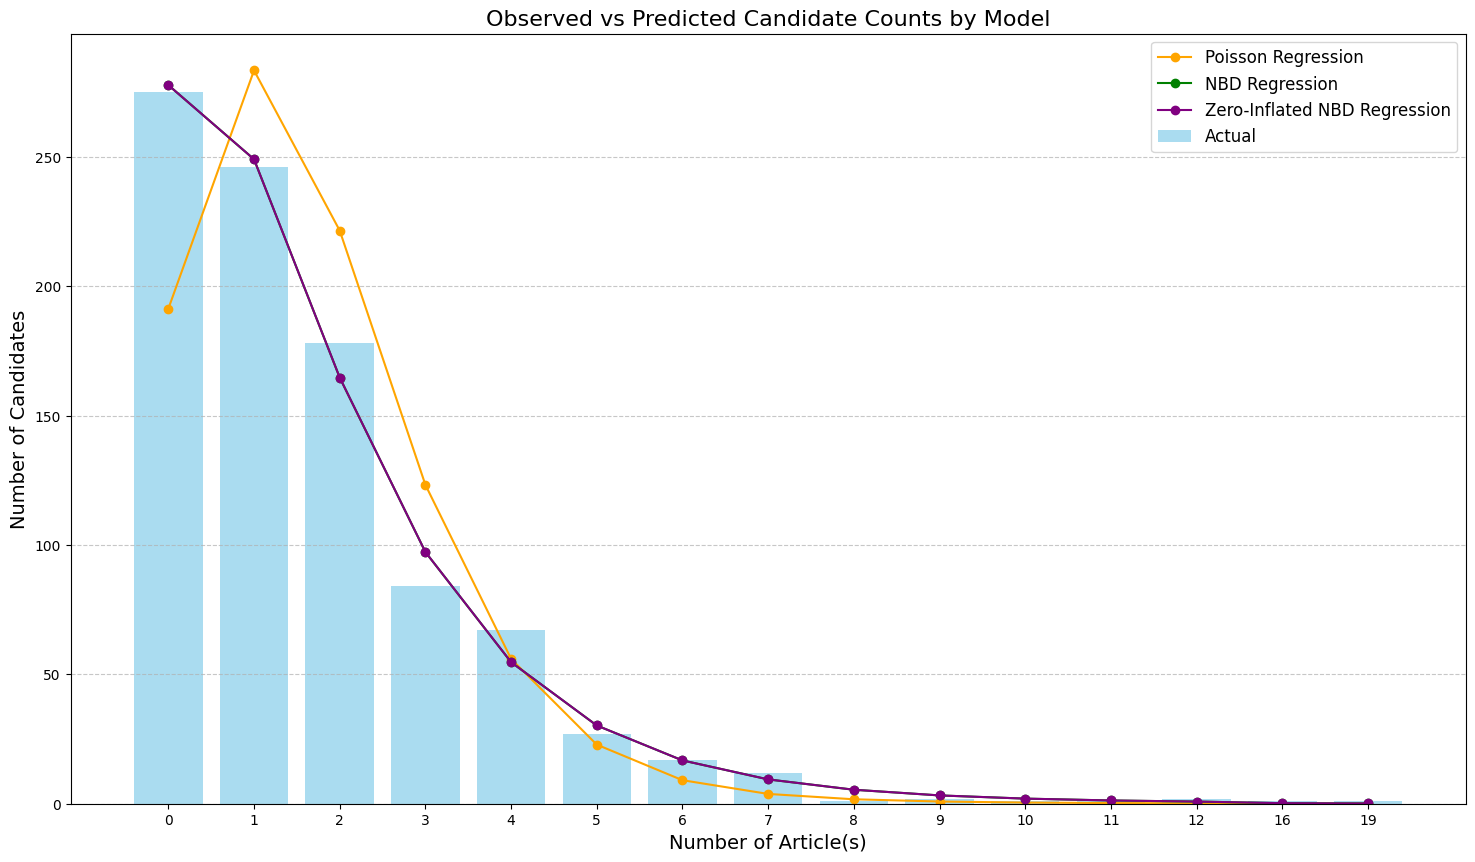

In [ ]:
# actual values
articles_actual_values = articles_df_predictions['Actual Number of Candidates'].values

# predictions from different models
articles_poisson_reg_predictions = articles_df_predictions['Poisson Regression Pred.'].values
articles_nbd_reg_predictions = articles_df_predictions['NBD Regression Pred.'].values
articles_zinbd_reg_predictions = articles_df_predictions['ZI-NBD Regression Pred.'].values

# set up the x-axis
x = np.arange(len(articles_actual_values))

# plot observed values as a bar chart
plt.figure(figsize=(18,10))
plt.bar(x, articles_actual_values, color='skyblue', label='Actual', alpha=0.7)

# plot predictions from each model as line graphs
plt.plot(x, articles_poisson_reg_predictions, color='orange', marker='o', linestyle='-', label='Poisson Regression')
plt.plot(x, articles_nbd_reg_predictions, color='green', marker='o', linestyle='-', label='NBD Regression')
plt.plot(x, articles_zinbd_reg_predictions, color='purple', marker='o', linestyle='-', label='Zero-Inflated NBD Regression')

# add labels, legends, and title
plt.xlabel('Number of Article(s)', fontsize = 14)
plt.ylabel('Number of Candidates', fontsize = 14)
plt.title('Observed vs Predicted Candidate Counts by Model', fontsize = 16)
plt.xticks(x, articles_df_predictions['Number of Articles'])
plt.legend(fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

# show the plot
plt.show()

In [ ]:
# store model results in a dictionary
models_articles = {'Poisson Regression': {'Number of Parameters': len(params_mle_poisson_reg_articles), 'Maximum Log-Likelihood': mll_poisson_reg_articles},
                'NBD Regression': {'Number of Parameters': len(params_mle_nbd_reg_articles), 'Maximum Log-Likelihood': mll_nbd_reg_articles},
                'ZI-NBD Regression': {'Number of Parameters': len(params_mle_zinbd_reg_articles), 'Maximum Log-Likelihood': mll_zinbd_reg_articles}
                }

# create summary dataframe
summary_articles = pd.DataFrame.from_dict(models_articles, orient = 'index')

# reset index to have 'Model' as a column
summary_articles = summary_articles.reset_index().rename(columns = {'index': 'Model'})

# calculate AIC and BIC
summary_articles['AIC'] = 2 * summary_articles['Number of Parameters'] - 2 * summary_articles['Maximum Log-Likelihood']
summary_articles['BIC'] = np.log(X.shape[0]) * summary_articles['Number of Parameters'] - 2 * summary_articles['Maximum Log-Likelihood']

summary_articles

,Model,Number of Parameters,Maximum Log-Likelihood,AIC,BIC
0,Poisson Regression,6,-1651.056547,3314.113095,3343.026639
1,NBD Regression,7,-1560.958341,3135.916683,3169.649151
2,ZI-NBD Regression,8,-1560.958389,3137.916779,3176.468171


In [ ]:
# sort the summary dataframe by AIC and BIC to get rankings
articles_aic_ranking = summary_articles.sort_values(by = 'AIC').reset_index(drop=True)
articles_bic_ranking = summary_articles.sort_values(by = 'BIC').reset_index(drop=True)

# add ranking columns for clarity
articles_aic_ranking['AIC Rank'] = range(1, len(articles_aic_ranking) + 1)
articles_bic_ranking['BIC Rank'] = range(1, len(articles_bic_ranking) + 1)

# display the rankings
print('Ranking by AIC (Lowest to Highest):')
print(articles_aic_ranking[['Model', 'AIC', 'AIC Rank']])

print('\nRanking by BIC (Lowest to Highest):')
print(articles_bic_ranking[['Model', 'BIC', 'BIC Rank']])

Ranking by AIC (Lowest to Highest):
                Model          AIC  AIC Rank
0      NBD Regression  3135.916683         1
1   ZI-NBD Regression  3137.916779         2
2  Poisson Regression  3314.113095         3

Ranking by BIC (Lowest to Highest):
                Model          BIC  BIC Rank
0      NBD Regression  3169.649151         1
1   ZI-NBD Regression  3176.468171         2
2  Poisson Regression  3343.026639         3


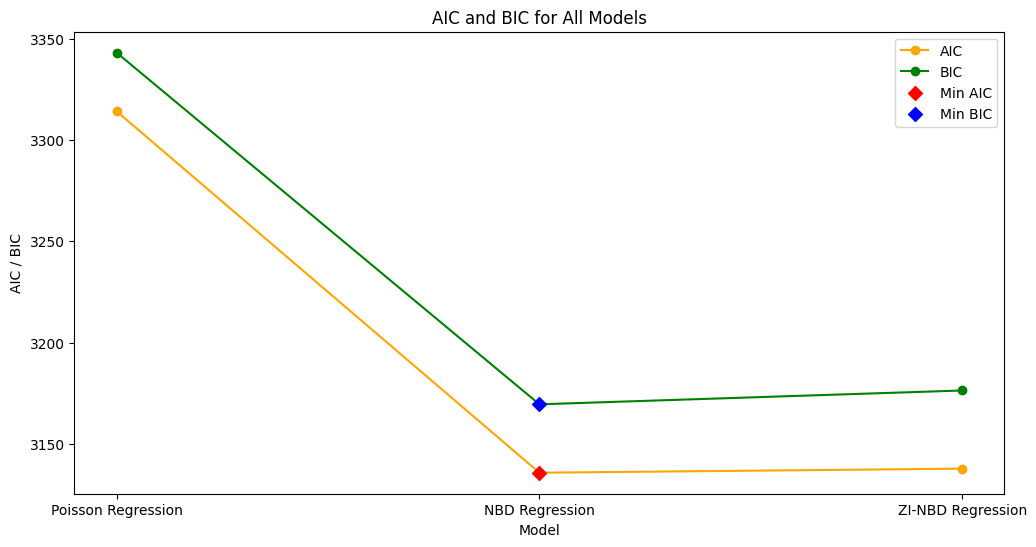

In [ ]:
# find the index of the minimum AIC and BIC values
min_aic_index = summary_articles['AIC'].idxmin()
min_bic_index = summary_articles['BIC'].idxmin()

# plot AIC and BIC by model
plt.figure(figsize=(12,6))

plt.plot(summary_articles['AIC'], color = 'orange', marker = 'o', label = 'AIC')
plt.plot(summary_articles['BIC'], color = 'green', marker = 'o', label = 'BIC')

# highlight the smallest AIC and BIC values
plt.scatter(min_aic_index, summary_articles['AIC'].min(), color = 'red', marker = 'D', s = 50, zorder = 5, label = 'Min AIC')
plt.scatter(min_bic_index, summary_articles['BIC'].min(), color = 'blue', marker = 'D', s = 50, zorder = 5, label = 'Min BIC')

# add labels, legends, and title
plt.xticks(ticks = np.arange(len(summary_articles['Model'])), labels = summary_articles['Model'])
plt.xlabel('Model')
plt.ylabel('AIC / BIC')
plt.legend()
plt.title('AIC and BIC for All Models')

# show the plot
plt.show()

In [ ]:
# define nested models for log-likelihood ratio test
pairs_to_compare = [('Poisson Regression', 'NBD Regression'), ('Poisson Regression', 'ZI-NBD Regression'), ('NBD Regression', 'ZI-NBD Regression')]

# initialize an empty list to store log-likelihood ratios
lrt_results_articles = []

# iterate through all possible pairs of models
for model1, model2 in pairs_to_compare:
  # get the log-likelihoods and number of parameters for the 2 models
  ll1 = summary_articles.loc[summary_articles['Model'] == model1, 'Maximum Log-Likelihood'].values[0]
  ll2 = summary_articles.loc[summary_articles['Model'] == model2, 'Maximum Log-Likelihood'].values[0]

  df1 = summary_articles.loc[summary_articles['Model'] == model1, 'Number of Parameters'].values[0]
  df2 = summary_articles.loc[summary_articles['Model'] == model2, 'Number of Parameters'].values[0]

  # log-likelihood ratio
  lr_stat = 2 * (ll2 - ll1)

  # calculate difference in df
  df_diff = abs(df2 - df1)

  # calculate p-value from chi-squared distribution
  p_value = 1 - chi2.cdf(lr_stat, df_diff)
  p_value = round(p_value, 5)
  better_model = model2 if p_value < 0.05 else model1

  # append the result
  lrt_results_articles.append({
        'Simple Model': model1,
        'Complex Model': model2,
        'Log-Likelihood Ratio': lr_stat,
        'Degrees of Freedom Difference': df_diff,
        'Chi-Squared p-value': p_value,
        'Better Model': better_model})

# create a dataframe to store the pairwise results
lrt_results_articles_df = pd.DataFrame(lrt_results_articles)

lrt_results_articles_df

,Simple Model,Complex Model,Log-Likelihood Ratio,Degrees of Freedom Difference,Chi-Squared p-value,Better Model
0,Poisson Regression,NBD Regression,180.196412,1,0.0,NBD Regression
1,Poisson Regression,ZI-NBD Regression,180.196316,2,0.0,ZI-NBD Regression
2,NBD Regression,ZI-NBD Regression,-0.000096,1,1.0,NBD Regression


Thank you for a great semester & enjoy the holidays! - Group 07

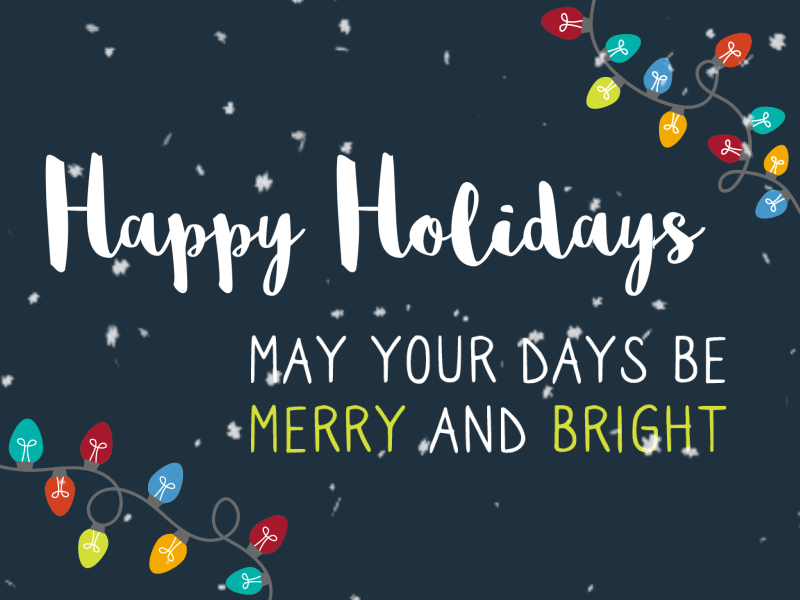